<a href="https://colab.research.google.com/github/haujla2391/CSCI-4170/blob/main/CSCI4170_hw6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1

S = 16 states (4 by 4 grid)

A = 4 actions (up, down, left, right)

R = +1 for reaching goal, 0 for stepping on ice, 0 for falling in hole

Gamma = 0.9

In [1]:
import gymnasium as gym
import numpy as np

In [2]:
env = gym.make("FrozenLake-v1", is_slippery=True)

state_size = env.observation_space.n
action_size = env.action_space.n

print(f"Number of States: {state_size}")
print(f"Number of Actions: {action_size}")

Number of States: 16
Number of Actions: 4


In [3]:
def value_iteration(P, nS, nA, gamma=0.9, theta=1e-8):
  V = np.zeros(nS)

  while True:
    delta = 0
    for s in range(nS):
      v = V[s]

      action_values = []
      for a in range(nA):
        q_sa = 0.0
        for prob, next_s, reward, done in P[s][a]:
          q_sa += prob * (reward + gamma * V[next_s])
        action_values.append(q_sa)

      V[s] = max(action_values)
      delta = max(delta, abs(v - V[s]))

    if delta < theta:
      break

  policy = np.zeros(nS, dtype=int)
  for s in range(nS):
      q_values = [
          sum(prob * (r + gamma * V[ns]) for prob, ns, r, _ in P[s][a])
          for a in range(nA)
      ]
      policy[s] = np.argmax(q_values)

  return V, policy

In [4]:
V, policy = value_iteration(env.unwrapped.P, state_size, action_size, gamma=0.9)

In [5]:
print("Learned Value Function (V):")
print(np.round(V.reshape(4, 4), 3))

print("\nLearned Policy:")
action_symbols = {0: '←', 1: '↓', 2: '→', 3: '↑'}
policy_symbols = np.array([action_symbols[a] for a in policy])
print(policy_symbols.reshape(4, 4))

Learned Value Function (V):
[[0.069 0.061 0.074 0.056]
 [0.092 0.    0.112 0.   ]
 [0.145 0.247 0.3   0.   ]
 [0.    0.38  0.639 0.   ]]

Learned Policy:
[['←' '↑' '←' '↑']
 ['←' '←' '←' '←']
 ['↑' '↓' '←' '←']
 ['←' '→' '↓' '←']]


In [6]:
n_episodes = 100
wins = 0
for ep in range(n_episodes):
    obs, _ = env.reset(seed=42 + ep)
    done = False
    while not done:
        obs, reward, terminated, truncated, _ = env.step(policy[obs])
        done = terminated or truncated
    if reward == 1.0:
        wins += 1
env.close()

win_rate = wins / n_episodes
print(f"Win rate: {win_rate * 100:.1f}%")

Win rate: 76.0%


In [7]:
gamma_new = 0.5
V_new, policy_new = value_iteration(env.unwrapped.P, state_size, action_size, gamma=gamma_new)

print(f"Learned Value Function (V) with gamma={gamma_new}:")
print(np.round(V_new.reshape(4, 4), 3))

print(f"\nLearned Policy with gamma={gamma_new}:")
action_symbols = {0: '←', 1: '↓', 2: '→', 3: '↑'}
policy_symbols_new = np.array([action_symbols[a] for a in policy_new])
print(policy_symbols_new.reshape(4, 4))

print("\n--- Comparison with original policy (gamma=0.9) ---")
print("Original Policy (gamma=0.9):")
print(policy_symbols.reshape(4, 4))

Learned Value Function (V) with gamma=0.5:
[[0.    0.001 0.003 0.001]
 [0.001 0.    0.013 0.   ]
 [0.006 0.029 0.077 0.   ]
 [0.    0.089 0.418 0.   ]]

Learned Policy with gamma=0.5:
[['↓' '↑' '→' '↑']
 ['←' '←' '←' '←']
 ['↑' '↓' '←' '←']
 ['←' '→' '↓' '←']]

--- Comparison with original policy (gamma=0.9) ---
Original Policy (gamma=0.9):
[['←' '↑' '←' '↑']
 ['←' '←' '←' '←']
 ['↑' '↓' '←' '←']
 ['←' '→' '↓' '←']]


This is an MDP because the next action and state only depend on the current state you are on. The history being the current state is enough to keep going. The learned policy is trying to reach the goal while also avoiding the holes and also accounting for slipperiness. It has to choose the safest path, not just the fastest.

# Task 2

### Diffusion Models

Paper: https://arxiv.org/pdf/2006.11239

Website: https://www.geeksforgeeks.org/artificial-intelligence/what-are-diffusion-models/

The problem that diffusion models are trying to solve is trying to learn a distribution to generate images. GANs have training instability and VAEs produce blurry images.

The idea is that an encoder uses a forward process to add Gaussian noise to an image, and then a decoder is trained to use a reverse process that learns how to denoise the image.

The architecture is an encoder and decoder and uses a U-Net for the decoder. The model minimizes the noise prediction error.

In [ ]:
from diffusers import StableDiffusionPipeline
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5"
).to(device)

prompt = "a futuristic city at sunset"

# Different step counts
steps_list = [10, 25, 50]

images = []
for steps in steps_list:
    image = pipe(prompt, num_inference_steps=steps).images[0]
    images.append((steps, image))

### Image generated with 10 inference steps:

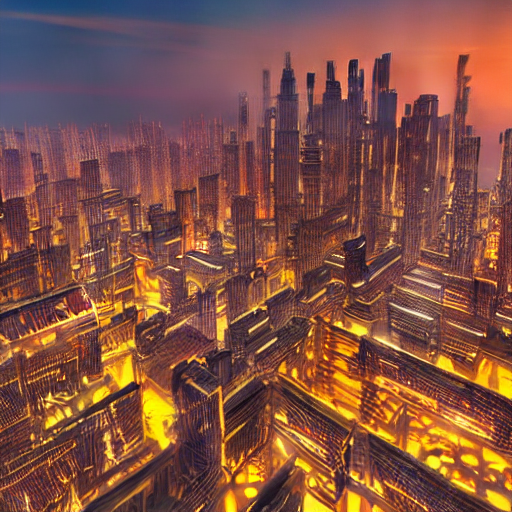

### Image generated with 25 inference steps:

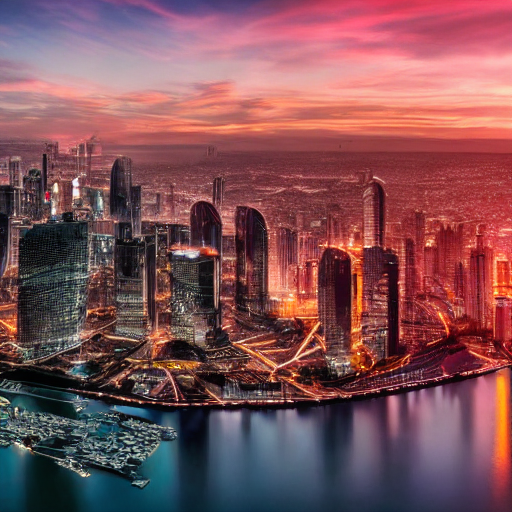

### Image generated with 50 inference steps:

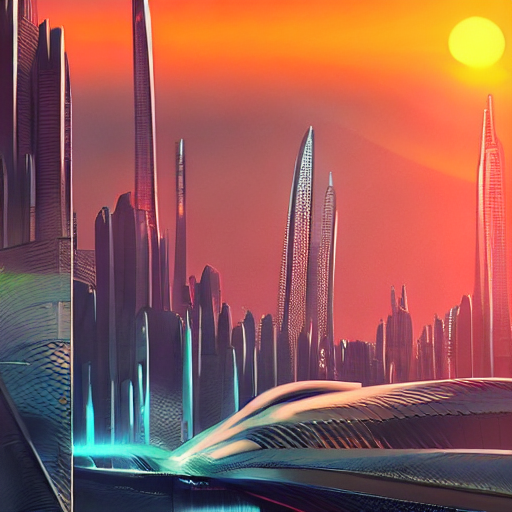

In [9]:
from IPython.display import display, Markdown

for steps, image in images:
    display(Markdown(f"### Image generated with {steps} inference steps:"))
    display(image)

### Limitations

There can be prompt sensitivity because a small difference in words can generate very different results. Also, these models are still very large and can take a lot of compute power.

### Extension

Test other schedulers such as DDPM or Euler schedulers and see if they can reach similar quality with fewer steps.